In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
from IPython.core.display import display, HTML
from matplotlib import pyplot as plt
from matplotlib import ticker as mpl_ticker
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmd7ynf
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: 2025-12-20-external-bb-reciporical
notebook path: /home/runner/work/oee4/oee4/binder/2025-12-20-external-bb-reciporical.ipynb
revision: bdac574
timestamp: 2026-02-01T17:24:53Z00:00

IPython==7.16.1
packaging==25.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-12-20-external-bb-reciporical"


In [5]:
df_all = []
for what, prefix in [
    ("nobb", "endeavor=16/external-competitions/stage=2+what=collated/"),
    ("swap-nobb", "endeavor=16/swap-external-competitions/stage=2+what=collated/"),
    ("selfbb", "endeavor=16/external-competitions-focalbb/stage=2+what=collated/"),
    ("truebb", "endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/"),
    ("swap-truebb", "endeavor=16/swap-external-competitions-focalbb-true/stage=2+what=collated/"),
    ("swap-selfbb", "endeavor=16/swap-external-competitions-focalbb/stage=2+what=collated/"),
]:
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket("prq49")


    competitions = bucket_handle.objects.filter(Prefix=prefix)
    dfs = [
        pd.read_csv(
          f's3://prq49/{competitions.key}',
        )
        for competitions in competitions
    ]
    print(len(dfs))
    df = pd.concat(dfs, ignore_index=True)
    df["kind"] = what

    df_all.append(df)

df = pd.concat(df_all, ignore_index=True)
df = df[
    (df["Competition Series"] == 16005)
]


100
98
100
99
101
101


In [6]:
palette = [
    sns.color_palette("Dark2")[2],
    sns.color_palette("Dark2")[1],
    sns.color_palette("Dark2")[4],
    sns.color_palette("Dark2")[3],
    sns.color_palette("Dark2")[0],
    sns.color_palette("Dark2")[5],
]

dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
]

dfx["Swap"] = dfx["kind"].str.contains("swap")
dfx["kind1"] = dfx["kind"].map({
    "nobb": "None",
    "swap-nobb": "None",
    "selfbb": "Self",
    "swap-truebb": "Ecological",
    "swap-selfbb": "Self",
    "truebb": "Ecological",
})


teeplots/2025-12-20-external-bb-reciporical/hue=kind1+kind=line+row=swap+style=kind1+viz=relplot+what=Ecological+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/hue=kind1+kind=line+row=swap+style=kind1+viz=relplot+what=Ecological+x=competition-stint+y=focal-prevalence+ext=.png


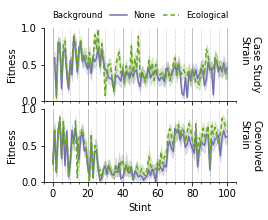

teeplots/2025-12-20-external-bb-reciporical/hue=kind1+kind=line+row=swap+style=kind1+viz=relplot+what=Self+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/hue=kind1+kind=line+row=swap+style=kind1+viz=relplot+what=Self+x=competition-stint+y=focal-prevalence+ext=.png


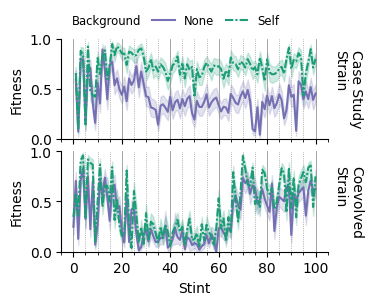

In [7]:
for what in "Ecological", "Self":
    with tp.teed(
        sns.relplot,
        data=dfx.replace(
            {
                True: "Coevolved\nStrain",
                False: "Case Study\nStrain",
            },
        ),
        x="Competition Stint",
        y="Focal Prevalence",
        row="Swap",
        hue="kind1",
        style="kind1",
        kind="line",
        legend=False,
        dashes=["", (4, 1, 1, 1), (3, 2)],
        facet_kws=dict(
            margin_titles=True,
        ),
        hue_order=["None", "", "Ecological" * (what == "Ecological"), "", "Self" * (what == "Self"), ""],
        palette=palette,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={
            "what": what,
        },
        teeplot_outexclude=["palette"],
    ) as g:
        g.figure.set_size_inches(3.5, 2.3)
        g.set(ylim=(0, 1), yticks=[0, 0.5, 1])
        g.set_titles(row_template="{row_name}")
        sns.lineplot(
            data=dfx.head(1),
            x="Competition Stint",
            y="Focal Prevalence",
            hue="kind1",
            style="kind1",
            ax=g.axes.flat[0],
            dashes=["", "", {
                "Ecological": (3, 2),
                "Self": (4, 1, 1, 1),
            }[what]],
            hue_order=["Background", "None", what],
            style_order=["Background", "None", what],
            palette=[
                "white",
                sns.color_palette("Dark2")[2],
                {
                    "Ecological": sns.color_palette("Dark2")[4],
                    "Self": sns.color_palette("Dark2")[0],
                }[what],
            ],
        )

        sns.move_legend(
            g.axes.flat[0],
            "upper left",
            bbox_to_anchor=(-0.12, 1.35),
            columnspacing=0.9,
            fontsize="small",
            frameon=False,
            ncol=4,
            title=None,
        )
        g.set(xlabel="Stint", ylabel="Fitness")
        g.figure.subplots_adjust(hspace=0.12)

        for ax in g.axes.flat:
            ax.xaxis.set_major_locator(mpl_ticker.MultipleLocator(20))
            ax.xaxis.set_minor_locator(mpl_ticker.MultipleLocator(5))

            ax.grid(which="major", axis="x", linestyle="-", linewidth="0.5", color="gray")
            ax.grid(which="minor", axis="x", linestyle=":", linewidth="0.5", color="gray")


teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Ecological+x=stint+y=prevalence-benefit+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Ecological+x=stint+y=prevalence-benefit+ext=.png


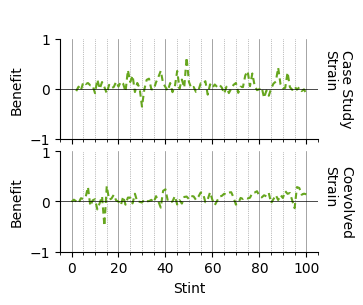

teeplots/2025-12-20-external-bb-reciporical/hue=stint+regplot=True+viz=scatterplot+what=Ecological+x=diff-nonswap+y=diff-swap+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/hue=stint+regplot=True+viz=scatterplot+what=Ecological+x=diff-nonswap+y=diff-swap+ext=.png


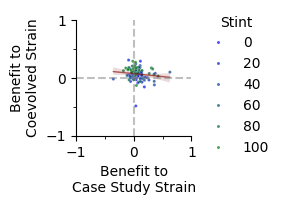

PearsonRResult(statistic=-0.1276065272281274, pvalue=0.21535379600984358)

SignificanceResult(statistic=-0.18727618014107433, pvalue=0.06768639796626533)

array([[50, 18],
       [22,  6]])


        scipy_stats.chi2_contingency(observed_data, correction=True)
    =Chi2ContingencyResult(statistic=0.06722689075630252, pvalue=0.7954180604830265, dof=1, expected_freq=array([[51., 17.],
       [21.,  7.]]))

        scipy_stats.fisher_exact(observed_data)
    =SignificanceResult(statistic=0.7575757575757576, pvalue=0.7960885484063265)



        scipy_stats.binomtest(
            k=(plot_data["diff_nonswap"] > 0).sum(), n=len(plot_data["diff_nonswap"].dropna())
        )
    =BinomTestResult(k=70, n=99, alternative='two-sided', statistic=0.7070707070707071, pvalue=4.606242964374745e-05)

        scipy_stats.binomtest(
            k=(plot_data["diff_swap"] > 0).sum(), n=len(plot_data["diff_swap"].dropna())
        )
    =BinomTestResult(k=73, n=98, alternative='two-sided', statistic=0.7448979591836735, pvalue=1.2796062450772919e-06)


teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Ecological+x=stint+y=prevalence-benefit+ext=.pdf


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Ecological+x=stint+y=prevalence-benefit+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Ecological+x=stint+y=prevalence-benefit+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Ecological+x=stint+y=prevalence-benefit+ext=.png


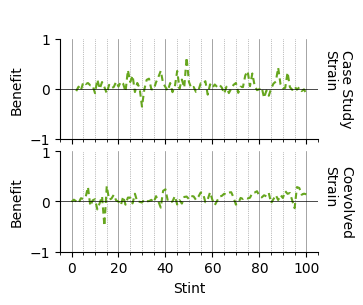

teeplots/2025-12-20-external-bb-reciporical/hue=stint+regplot=False+viz=scatterplot+what=Ecological+x=diff-nonswap+y=diff-swap+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/hue=stint+regplot=False+viz=scatterplot+what=Ecological+x=diff-nonswap+y=diff-swap+ext=.png


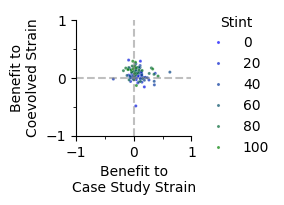

PearsonRResult(statistic=-0.1276065272281274, pvalue=0.21535379600984358)

SignificanceResult(statistic=-0.18727618014107433, pvalue=0.06768639796626533)

array([[50, 18],
       [22,  6]])


        scipy_stats.chi2_contingency(observed_data, correction=True)
    =Chi2ContingencyResult(statistic=0.06722689075630252, pvalue=0.7954180604830265, dof=1, expected_freq=array([[51., 17.],
       [21.,  7.]]))

        scipy_stats.fisher_exact(observed_data)
    =SignificanceResult(statistic=0.7575757575757576, pvalue=0.7960885484063265)



        scipy_stats.binomtest(
            k=(plot_data["diff_nonswap"] > 0).sum(), n=len(plot_data["diff_nonswap"].dropna())
        )
    =BinomTestResult(k=70, n=99, alternative='two-sided', statistic=0.7070707070707071, pvalue=4.606242964374745e-05)

        scipy_stats.binomtest(
            k=(plot_data["diff_swap"] > 0).sum(), n=len(plot_data["diff_swap"].dropna())
        )
    =BinomTestResult(k=73, n=98, alternative='two-sided', statistic=0.7448979591836735, pvalue=1.2796062450772919e-06)


teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Self+x=stint+y=prevalence-benefit+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Self+x=stint+y=prevalence-benefit+ext=.png


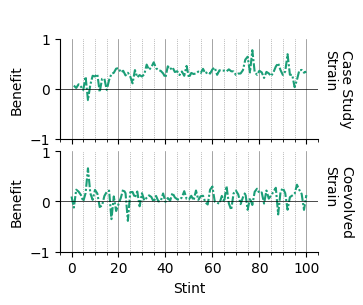

teeplots/2025-12-20-external-bb-reciporical/hue=stint+regplot=True+viz=scatterplot+what=Self+x=diff-nonswap+y=diff-swap+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/hue=stint+regplot=True+viz=scatterplot+what=Self+x=diff-nonswap+y=diff-swap+ext=.png


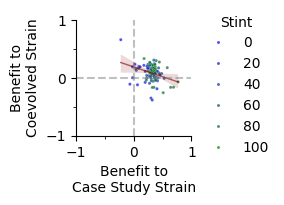

PearsonRResult(statistic=-0.33017121823850687, pvalue=0.0009572837378091723)

SignificanceResult(statistic=-0.23980906795707974, pvalue=0.01798822904860496)

array([[70, 23],
       [ 3,  1]])


        scipy_stats.chi2_contingency(observed_data, correction=True)
    =Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=1, expected_freq=array([[69.98969072, 23.01030928],
       [ 3.01030928,  0.98969072]]))

        scipy_stats.fisher_exact(observed_data)
    =SignificanceResult(statistic=1.0144927536231885, pvalue=1.0)



        scipy_stats.binomtest(
            k=(plot_data["diff_nonswap"] > 0).sum(), n=len(plot_data["diff_nonswap"].dropna())
        )
    =BinomTestResult(k=96, n=100, alternative='two-sided', statistic=0.96, pvalue=6.449688895763542e-24)

        scipy_stats.binomtest(
            k=(plot_data["diff_swap"] > 0).sum(), n=len(plot_data["diff_swap"].dropna())
        )
    =BinomTestResult(k=74, n=98, alternative='two-sided', statistic=0.7551020408163265, pvalue=4.2159207369916054e-07)


teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Self+x=stint+y=prevalence-benefit+ext=.pdf


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Self+x=stint+y=prevalence-benefit+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Self+x=stint+y=prevalence-benefit+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-12-20-external-bb-reciporical/kind=line+row=source+style=kind1+viz=relplot+what=Self+x=stint+y=prevalence-benefit+ext=.png


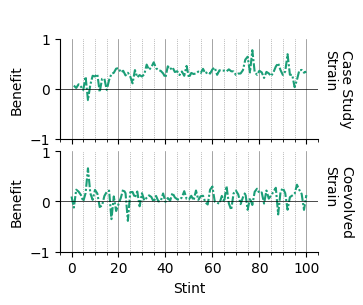

teeplots/2025-12-20-external-bb-reciporical/hue=stint+regplot=False+viz=scatterplot+what=Self+x=diff-nonswap+y=diff-swap+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/hue=stint+regplot=False+viz=scatterplot+what=Self+x=diff-nonswap+y=diff-swap+ext=.png


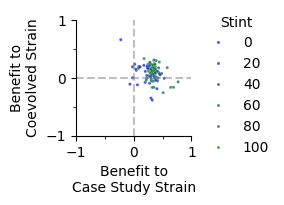

PearsonRResult(statistic=-0.33017121823850687, pvalue=0.0009572837378091723)

SignificanceResult(statistic=-0.23980906795707974, pvalue=0.01798822904860496)

array([[70, 23],
       [ 3,  1]])


        scipy_stats.chi2_contingency(observed_data, correction=True)
    =Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=1, expected_freq=array([[69.98969072, 23.01030928],
       [ 3.01030928,  0.98969072]]))

        scipy_stats.fisher_exact(observed_data)
    =SignificanceResult(statistic=1.0144927536231885, pvalue=1.0)



        scipy_stats.binomtest(
            k=(plot_data["diff_nonswap"] > 0).sum(), n=len(plot_data["diff_nonswap"].dropna())
        )
    =BinomTestResult(k=96, n=100, alternative='two-sided', statistic=0.96, pvalue=6.449688895763542e-24)

        scipy_stats.binomtest(
            k=(plot_data["diff_swap"] > 0).sum(), n=len(plot_data["diff_swap"].dropna())
        )
    =BinomTestResult(k=74, n=98, alternative='two-sided', statistic=0.7551020408163265, pvalue=4.2159207369916054e-07)


In [8]:
# 1. Prepare the data: Pivot so Swap/Non-Swap are columns
# We use Competition Stint as the index to match pairs correctly
df_pivot = dfx[
    [
        "Competition Stint",
        "kind1",
        "Swap",
        "Focal Prevalence",
    ]
].groupby(
    [
        "Competition Stint",
        "kind1",
        "Swap",
    ],
).mean().reset_index().pivot_table(
    index=["Competition Stint", "kind1"],
    columns="Swap",
    values="Focal Prevalence"
).reset_index().copy()

# Rename columns for clarity: False is 'No Swap', True is 'Swap'
assert [*df_pivot.columns] == ["Competition Stint", "kind1", False, True], df_pivot.columns
df_pivot.columns = ["Stint", "kind1", "NonSwap_Val", "Swap_Val"]

# 2. Calculate the "None" baseline for each Stint
baselines = df_pivot[df_pivot["kind1"] == "None"][["Stint", "NonSwap_Val", "Swap_Val"]]
df_merged = df_pivot.merge(baselines, on="Stint", suffixes=("", "_None"))

# 3. Calculate the Differences
df_merged["diff_nonswap"] = df_merged["NonSwap_Val"] - df_merged["NonSwap_Val_None"]
df_merged["diff_swap"] = df_merged["Swap_Val"] - df_merged["Swap_Val_None"]

# 4. Plotting
for what, regplot in it.product(
    ["Ecological", "Self"],
    [True, False],
):
    display(HTML(f"<h1>{what=}</h1>"))
    plot_data = df_merged[df_merged["kind1"] == what].copy()

    with tp.teed(
        sns.relplot,
        plot_data.melt(
            id_vars=["Stint", "kind1"],
            value_vars=["diff_nonswap", "diff_swap"],
            value_name="Prevalence Benefit",
            var_name="source",
        ).replace(
            {
                "diff_nonswap": "Case Study\nStrain",
                "diff_swap": "Coevolved\nStrain",
            },
        ),
        x="Stint",
        y="Prevalence Benefit",
        style="kind1",
        row="source",
        color={
            "Ecological": palette[2],
            "Self": palette[4],
        }[what],
        dashes=[
            {
                "Ecological": (3, 2),
                "Self": (4, 1, 1, 1),
            }[what],
        ],
        facet_kws=dict(
            margin_titles=True,
        ),
        kind="line",
        legend=False,
        lw=1.5,
        teeplot_outattrs={
            "what": what,
        },
        teeplot_outexclude=["palette"],
        teeplot_subdir=teeplot_subdir,
    ) as g:
        g.figure.set_size_inches(3.5, 2.3)
        g.set(ylim=(-1, 1), yticks=[-1, 0, 1])
        g.set_titles(row_template="{row_name}")
        sns.lineplot(
            data=dfx.head(1),
            x="Competition Stint",
            y="Focal Prevalence",
            hue="kind1",
            style="kind1",
            ax=g.axes.flat[0],
            dashes=["", ""],
            hue_order=["", " "],
            style_order=["", " "],
            palette=["white", "white"],
        )
        sns.move_legend(
            g.axes.flat[0],
            "upper left",
            bbox_to_anchor=(-0.12, 1.35),
            columnspacing=0.9,
            fontsize="small",
            frameon=False,
            ncol=4,
            title=None,
        )
        g.set(xlabel="Stint", ylabel="Benefit")
        g.figure.subplots_adjust(hspace=0.12)

        for ax in g.axes.flat:
            ax.axhline(0, linewidth=0.5, color="black")
            ax.xaxis.set_major_locator(mpl_ticker.MultipleLocator(20))
            ax.xaxis.set_minor_locator(mpl_ticker.MultipleLocator(5))

            ax.grid(which="major", axis="x", linestyle="-", linewidth="0.5", color="gray")
            ax.grid(which="minor", axis="x", linestyle=":", linewidth="0.5", color="gray")


    with tp.teed(
        sns.scatterplot,
        data=plot_data,
        x="diff_nonswap",
        y="diff_swap",
        hue="Stint",
        alpha=0.7,
        hue_norm=(0, 100),
        palette="blend:blue,green",
        s=5,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={
            "regplot": regplot,
            "what": what,
        },
        teeplot_outexclude=["palette"],
    ) as ax:
        if regplot:
            sns.regplot(
                data=plot_data,
                x="diff_nonswap",
                y="diff_swap",
                ax=ax,
                line_kws=dict(alpha=0.6, color="maroon", lw=1),
                scatter_kws=dict(alpha=0.0),
            )
        ax.axvline(0, color="gray", ls="--", alpha=0.5)
        ax.axhline(0, color="gray", ls="--", alpha=0.5)
        # Formatting
        ax.set_xlabel("Benefit to\nCase Study Strain")
        ax.set_ylabel("Benefit to\nCoevolved Strain")

        sns.despine(ax=ax)
        sns.move_legend(
            ax,"upper left", bbox_to_anchor=(1, 1.15), frameon=False,
        )
        ax.figure.set_size_inches(1.5, 1.5)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.set_xticks([-0.5, 0.5], minor=True)
        ax.set_yticks([-0.5, 0.5], minor=True)

    display(
        scipy_stats.pearsonr(
            plot_data.dropna()["diff_nonswap"],
            plot_data.dropna()["diff_swap"],
        )
    )
    display(
        scipy_stats.spearmanr(
            plot_data.dropna()["diff_nonswap"],
            plot_data.dropna()["diff_swap"],
        )
    )
    display(HTML("<hr>"))

    pp = ((plot_data["diff_nonswap"] > 0) & (plot_data["diff_swap"] > 0)).sum()
    pm = ((plot_data["diff_nonswap"] > 0) & (plot_data["diff_swap"] <= 0)).sum()
    mp = ((plot_data["diff_nonswap"] <= 0) & (plot_data["diff_swap"] > 0)).sum()
    mm = ((plot_data["diff_nonswap"] <= 0) & (plot_data["diff_swap"] <= 0)).sum()

    observed_data = np.array([
        [pp, pm],
        [mp, mm]
    ])
    display(observed_data)
    display(HTML("<hr>"))

    print(f"""{
        scipy_stats.chi2_contingency(observed_data, correction=True)
    =}""")
    print(f"""{
        scipy_stats.fisher_exact(observed_data)
    =}""")
    display(HTML("<hr>"))

    print(f"""{
        scipy_stats.binomtest(
            k=(plot_data["diff_nonswap"] > 0).sum(), n=len(plot_data["diff_nonswap"].dropna())
        )
    =}""")
    print(f"""{
        scipy_stats.binomtest(
            k=(plot_data["diff_swap"] > 0).sum(), n=len(plot_data["diff_swap"].dropna())
        )
    =}""")
    display(HTML("<hr>"))


teeplots/2025-12-20-external-bb-reciporical/how=absolute+hue=stint+regplot=True+viz=scatterplot+what=diff_nonswap+x=ecological+y=self+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/how=absolute+hue=stint+regplot=True+viz=scatterplot+what=diff_nonswap+x=ecological+y=self+ext=.png


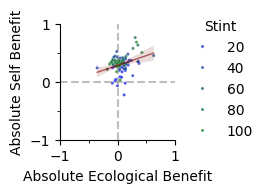

PearsonRResult(statistic=0.32342568083601547, pvalue=0.0010930718440706386)

SignificanceResult(statistic=0.22304267161410019, pvalue=0.026480204589921796)

array([[68,  2],
       [27,  2]])

scipy_stats.chi2_contingency(observed_data, correction=True)=Chi2ContingencyResult(statistic=0.1355571039668135, pvalue=0.7127384232385432, dof=1, expected_freq=array([[67.17171717,  2.82828283],
       [27.82828283,  1.17171717]]))
scipy_stats.fisher_exact(observed_data)=SignificanceResult(statistic=2.5185185185185186, pvalue=0.5782939855104804)


Ecological Binom: BinomTestResult(k=70, n=99, alternative='two-sided', statistic=0.7070707070707071, pvalue=4.606242964374745e-05)
Self Binom: BinomTestResult(k=95, n=99, alternative='two-sided', statistic=0.9595959595959596, pvalue=1.2388827013668045e-23)


teeplots/2025-12-20-external-bb-reciporical/how=absolute+hue=stint+regplot=False+viz=scatterplot+what=diff_nonswap+x=ecological+y=self+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/how=absolute+hue=stint+regplot=False+viz=scatterplot+what=diff_nonswap+x=ecological+y=self+ext=.png


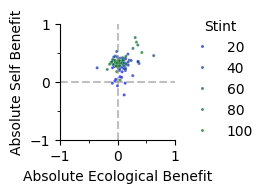

PearsonRResult(statistic=0.32342568083601547, pvalue=0.0010930718440706386)

SignificanceResult(statistic=0.22304267161410019, pvalue=0.026480204589921796)

array([[68,  2],
       [27,  2]])

scipy_stats.chi2_contingency(observed_data, correction=True)=Chi2ContingencyResult(statistic=0.1355571039668135, pvalue=0.7127384232385432, dof=1, expected_freq=array([[67.17171717,  2.82828283],
       [27.82828283,  1.17171717]]))
scipy_stats.fisher_exact(observed_data)=SignificanceResult(statistic=2.5185185185185186, pvalue=0.5782939855104804)


Ecological Binom: BinomTestResult(k=70, n=99, alternative='two-sided', statistic=0.7070707070707071, pvalue=4.606242964374745e-05)
Self Binom: BinomTestResult(k=95, n=99, alternative='two-sided', statistic=0.9595959595959596, pvalue=1.2388827013668045e-23)


teeplots/2025-12-20-external-bb-reciporical/how=absolute+hue=stint+regplot=True+viz=scatterplot+what=diff_swap+x=ecological+y=self+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/how=absolute+hue=stint+regplot=True+viz=scatterplot+what=diff_swap+x=ecological+y=self+ext=.png


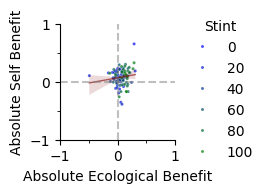

PearsonRResult(statistic=0.1327463900142235, pvalue=0.19256237884074434)

SignificanceResult(statistic=0.11928032693864797, pvalue=0.24206279018060745)

array([[55, 18],
       [19,  6]])

scipy_stats.chi2_contingency(observed_data, correction=True)=Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=1, expected_freq=array([[55.12244898, 17.87755102],
       [18.87755102,  6.12244898]]))
scipy_stats.fisher_exact(observed_data)=SignificanceResult(statistic=0.9649122807017544, pvalue=1.0)


Ecological Binom: BinomTestResult(k=73, n=98, alternative='two-sided', statistic=0.7448979591836735, pvalue=1.2796062450772919e-06)
Self Binom: BinomTestResult(k=74, n=98, alternative='two-sided', statistic=0.7551020408163265, pvalue=4.2159207369916054e-07)


teeplots/2025-12-20-external-bb-reciporical/how=absolute+hue=stint+regplot=False+viz=scatterplot+what=diff_swap+x=ecological+y=self+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/how=absolute+hue=stint+regplot=False+viz=scatterplot+what=diff_swap+x=ecological+y=self+ext=.png


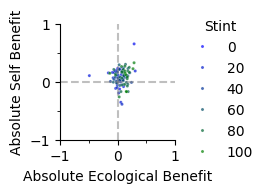

PearsonRResult(statistic=0.1327463900142235, pvalue=0.19256237884074434)

SignificanceResult(statistic=0.11928032693864797, pvalue=0.24206279018060745)

array([[55, 18],
       [19,  6]])

scipy_stats.chi2_contingency(observed_data, correction=True)=Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=1, expected_freq=array([[55.12244898, 17.87755102],
       [18.87755102,  6.12244898]]))
scipy_stats.fisher_exact(observed_data)=SignificanceResult(statistic=0.9649122807017544, pvalue=1.0)


Ecological Binom: BinomTestResult(k=73, n=98, alternative='two-sided', statistic=0.7448979591836735, pvalue=1.2796062450772919e-06)
Self Binom: BinomTestResult(k=74, n=98, alternative='two-sided', statistic=0.7551020408163265, pvalue=4.2159207369916054e-07)


In [9]:
# 1. Prepare the data: Calculate differences from 'None' first
# We need to preserve 'kind1' to separate Ecological/Self
df_pivot = dfx[
    [
        "Competition Stint",
        "kind1",
        "Swap",
        "Focal Prevalence",
    ]
].groupby(
    [
        "Competition Stint",
        "kind1",
        "Swap",
    ],
).mean().reset_index().pivot_table(
    index=["Competition Stint", "kind1"],
    columns="Swap",
    values="Focal Prevalence"
).reset_index().copy()

assert [*df_pivot.columns] == ["Competition Stint", "kind1", False, True], df_pivot.columns
df_pivot.columns = ["Stint", "kind1", "NonSwap_Val", "Swap_Val"]

# Calculate baselines per Stint
baselines = df_pivot[df_pivot["kind1"] == "None"][["Stint", "NonSwap_Val", "Swap_Val"]]
df_merged = df_pivot.merge(baselines, on="Stint", suffixes=("", "_None"))

# Calculate the raw differences from 'None'
df_merged["diff_nonswap"] = df_merged["NonSwap_Val"] - df_merged["NonSwap_Val_None"]
df_merged["diff_swap"] = df_merged["Swap_Val"] - df_merged["Swap_Val_None"]

# 2. Pivot again to align Ecological vs Self differences as paired columns
# We do this for both Swap and Non-Swap
df_final = df_merged[df_merged["kind1"] != "None"].pivot(
    index="Stint",
    columns="kind1",
    values=["diff_nonswap", "diff_swap"]
)

# 3. Plotting loop: Compare Ecological vs Self for each Swap condition
for swap_type, regplot in it.product(
    ["diff_nonswap", "diff_swap"],
    [True, False],
):
    display(HTML(f"<h1>{swap_type=}</h1>"))
    plot_data = df_final[swap_type].dropna()

    with tp.teed(
        sns.scatterplot,
        data=plot_data,
        x="Ecological",
        y="Self",
        hue="Stint",
        alpha=0.7,
        hue_norm=(0, 100),
        palette="blend:blue,green",
        s=5,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={
            "how": "absolute",
            "regplot": regplot,
            "what": swap_type,
        },
        teeplot_outexclude=["palette"],
    ) as ax:
        if regplot:
            sns.regplot(
                data=plot_data,
                x="Ecological",
                y="Self",
                ax=ax,
                line_kws=dict(alpha=0.6, color="maroon", lw=1),
                scatter_kws=dict(alpha=0.0),
            )
        ax.figure.set_size_inches(1.5, 1.5)
        ax.axvline(0, color="gray", ls="--", alpha=0.5)
        ax.axhline(0, color="gray", ls="--", alpha=0.5)
        # Formatting
        ax.set_xlabel("Absolute Ecological Benefit")
        ax.set_ylabel("Absolute Self Benefit")

        ax.set_aspect("equal", adjustable="box")
        sns.despine(ax=ax)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        sns.move_legend(
            ax,"upper left", bbox_to_anchor=(1, 1.15), frameon=False,
        )
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.set_xticks([-0.5, 0.5], minor=True)
        ax.set_yticks([-0.5, 0.5], minor=True)

    # Statistical Tests
    display(scipy_stats.pearsonr(plot_data["Ecological"], plot_data["Self"]))
    display(scipy_stats.spearmanr(plot_data["Ecological"], plot_data["Self"]))
    display(HTML("<hr>"))

    # Quadrant Counts (Independence of Ecological vs Self axes)
    pp = ((plot_data["Ecological"] > 0) & (plot_data["Self"] > 0)).sum()
    pm = ((plot_data["Ecological"] > 0) & (plot_data["Self"] <= 0)).sum()
    mp = ((plot_data["Ecological"] <= 0) & (plot_data["Self"] > 0)).sum()
    mm = ((plot_data["Ecological"] <= 0) & (plot_data["Self"] <= 0)).sum()

    observed_data = np.array([[pp, pm], [mp, mm]])
    display(HTML(f"<b>Contingency Table (++, +-, -+, --):</b>"))
    display(observed_data)

    # Independence Tests
    print(f"{scipy_stats.chi2_contingency(observed_data, correction=True)=}")
    print(f"{scipy_stats.fisher_exact(observed_data)=}")
    display(HTML("<hr>"))

    # Binomial Tests (Is one axis biased toward positive?)
    print(f"Ecological Binom: {scipy_stats.binomtest(k=(plot_data['Ecological'] > 0).sum(), n=len(plot_data))}")
    print(f"Self Binom: {scipy_stats.binomtest(k=(plot_data['Self'] > 0).sum(), n=len(plot_data))}")
    display(HTML("<hr>"))


teeplots/2025-12-20-external-bb-reciporical/how=relative+hue=stint+regplot=True+viz=scatterplot+what=diff_nonswap+x=ecological+y=self+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/how=relative+hue=stint+regplot=True+viz=scatterplot+what=diff_nonswap+x=ecological+y=self+ext=.png


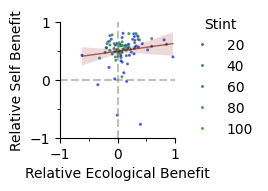

PearsonRResult(statistic=0.1344159201929793, pvalue=0.18468592926099392)

SignificanceResult(statistic=0.2333333333333333, pvalue=0.02010761379487701)

array([[68,  2],
       [27,  2]])

scipy_stats.chi2_contingency(observed_data, correction=True)=Chi2ContingencyResult(statistic=0.1355571039668135, pvalue=0.7127384232385432, dof=1, expected_freq=array([[67.17171717,  2.82828283],
       [27.82828283,  1.17171717]]))
scipy_stats.fisher_exact(observed_data)=SignificanceResult(statistic=2.5185185185185186, pvalue=0.5782939855104804)


Ecological Binom: BinomTestResult(k=70, n=99, alternative='two-sided', statistic=0.7070707070707071, pvalue=4.606242964374745e-05)
Self Binom: BinomTestResult(k=95, n=99, alternative='two-sided', statistic=0.9595959595959596, pvalue=1.2388827013668045e-23)


teeplots/2025-12-20-external-bb-reciporical/how=relative+hue=stint+regplot=False+viz=scatterplot+what=diff_nonswap+x=ecological+y=self+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/how=relative+hue=stint+regplot=False+viz=scatterplot+what=diff_nonswap+x=ecological+y=self+ext=.png


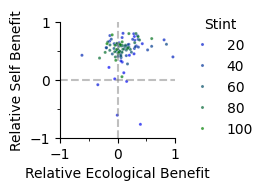

PearsonRResult(statistic=0.1344159201929793, pvalue=0.18468592926099392)

SignificanceResult(statistic=0.2333333333333333, pvalue=0.02010761379487701)

array([[68,  2],
       [27,  2]])

scipy_stats.chi2_contingency(observed_data, correction=True)=Chi2ContingencyResult(statistic=0.1355571039668135, pvalue=0.7127384232385432, dof=1, expected_freq=array([[67.17171717,  2.82828283],
       [27.82828283,  1.17171717]]))
scipy_stats.fisher_exact(observed_data)=SignificanceResult(statistic=2.5185185185185186, pvalue=0.5782939855104804)


Ecological Binom: BinomTestResult(k=70, n=99, alternative='two-sided', statistic=0.7070707070707071, pvalue=4.606242964374745e-05)
Self Binom: BinomTestResult(k=95, n=99, alternative='two-sided', statistic=0.9595959595959596, pvalue=1.2388827013668045e-23)


teeplots/2025-12-20-external-bb-reciporical/how=relative+hue=stint+regplot=True+viz=scatterplot+what=diff_swap+x=ecological+y=self+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/how=relative+hue=stint+regplot=True+viz=scatterplot+what=diff_swap+x=ecological+y=self+ext=.png


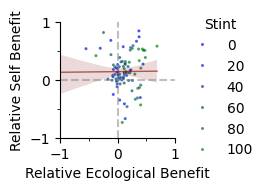

PearsonRResult(statistic=0.008094495977406272, pvalue=0.9369494457545628)

SignificanceResult(statistic=0.08733877806042753, pvalue=0.3924669685584191)

array([[55, 18],
       [19,  6]])

scipy_stats.chi2_contingency(observed_data, correction=True)=Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=1, expected_freq=array([[55.12244898, 17.87755102],
       [18.87755102,  6.12244898]]))
scipy_stats.fisher_exact(observed_data)=SignificanceResult(statistic=0.9649122807017544, pvalue=1.0)


Ecological Binom: BinomTestResult(k=73, n=98, alternative='two-sided', statistic=0.7448979591836735, pvalue=1.2796062450772919e-06)
Self Binom: BinomTestResult(k=74, n=98, alternative='two-sided', statistic=0.7551020408163265, pvalue=4.2159207369916054e-07)


teeplots/2025-12-20-external-bb-reciporical/how=relative+hue=stint+regplot=False+viz=scatterplot+what=diff_swap+x=ecological+y=self+ext=.pdf
teeplots/2025-12-20-external-bb-reciporical/how=relative+hue=stint+regplot=False+viz=scatterplot+what=diff_swap+x=ecological+y=self+ext=.png


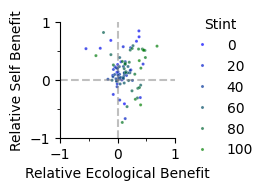

PearsonRResult(statistic=0.008094495977406272, pvalue=0.9369494457545628)

SignificanceResult(statistic=0.08733877806042753, pvalue=0.3924669685584191)

array([[55, 18],
       [19,  6]])

scipy_stats.chi2_contingency(observed_data, correction=True)=Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=1, expected_freq=array([[55.12244898, 17.87755102],
       [18.87755102,  6.12244898]]))
scipy_stats.fisher_exact(observed_data)=SignificanceResult(statistic=0.9649122807017544, pvalue=1.0)


Ecological Binom: BinomTestResult(k=73, n=98, alternative='two-sided', statistic=0.7448979591836735, pvalue=1.2796062450772919e-06)
Self Binom: BinomTestResult(k=74, n=98, alternative='two-sided', statistic=0.7551020408163265, pvalue=4.2159207369916054e-07)


In [10]:
# 1. Prepare the data: Calculate differences from 'None' first
# We need to preserve 'kind1' to separate Ecological/Self
df_pivot = dfx[
    [
        "Competition Stint",
        "kind1",
        "Swap",
        "Focal Prevalence",
    ]
].groupby(
    [
        "Competition Stint",
        "kind1",
        "Swap",
    ],
).mean().reset_index().pivot_table(
    index=["Competition Stint", "kind1"],
    columns="Swap",
    values="Focal Prevalence"
).reset_index()
assert [*df_pivot.columns] == ["Competition Stint", "kind1", False, True], df_pivot.columns
df_pivot.columns = ["Stint", "kind1", "NonSwap_Val", "Swap_Val"]

# Calculate baselines per Stint
baselines = df_pivot[df_pivot["kind1"] == "None"][["Stint", "NonSwap_Val", "Swap_Val"]]
df_merged = df_pivot.merge(baselines, on="Stint", suffixes=("", "_None"))

# Calculate the raw differences from 'None'
df_merged["diff_nonswap"] = (
    df_merged["NonSwap_Val"] - df_merged["NonSwap_Val_None"]
) / (1 - df_merged["NonSwap_Val_None"])
df_merged["diff_swap"] = (
    df_merged["Swap_Val"] - df_merged["Swap_Val_None"]
) / (1 - df_merged["Swap_Val_None"])

# 2. Pivot again to align Ecological vs Self differences as paired columns
# We do this for both Swap and Non-Swap
df_final = df_merged[df_merged["kind1"] != "None"].pivot(
    index="Stint",
    columns="kind1",
    values=["diff_nonswap", "diff_swap"]
)

# 3. Plotting loop: Compare Ecological vs Self for each Swap condition
for swap_type, regplot in it.product(
    ["diff_nonswap", "diff_swap"],
    [True, False],
):
    display(HTML(f"<h1>{swap_type=}</h1>"))
    plot_data = df_final[swap_type].dropna()

    with tp.teed(
        sns.scatterplot,
        data=plot_data,
        x="Ecological",
        y="Self",
        hue="Stint",
        alpha=0.7,
        hue_norm=(0, 100),
        palette="blend:blue,green",
        s=5,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={
            "how": "relative",
            "regplot": regplot,
            "what": swap_type,
        },
        teeplot_outexclude=["palette"],
    ) as ax:
        if regplot:
            sns.regplot(
                data=plot_data,
                x="Ecological",
                y="Self",
                ax=ax,
                line_kws=dict(alpha=0.6, color="maroon", lw=1),
                scatter_kws=dict(alpha=0.0),
            )
        ax.figure.set_size_inches(1.5, 1.5)
        ax.axvline(0, color="gray", ls="--", alpha=0.5)
        ax.axhline(0, color="gray", ls="--", alpha=0.5)
        # Formatting
        ax.set_xlabel("Relative Ecological Benefit")
        ax.set_ylabel("Relative Self Benefit")

        ax.set_aspect("equal", adjustable="box")
        sns.despine(ax=ax)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        sns.move_legend(
            ax,"upper left", bbox_to_anchor=(1, 1.15), frameon=False,
        )
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.set_xticks([-0.5, 0.5], minor=True)
        ax.set_yticks([-0.5, 0.5], minor=True)

    # Statistical Tests
    display(scipy_stats.pearsonr(plot_data["Ecological"], plot_data["Self"]))
    display(scipy_stats.spearmanr(plot_data["Ecological"], plot_data["Self"]))
    display(HTML("<hr>"))

    # Quadrant Counts (Independence of Ecological vs Self axes)
    pp = ((plot_data["Ecological"] > 0) & (plot_data["Self"] > 0)).sum()
    pm = ((plot_data["Ecological"] > 0) & (plot_data["Self"] <= 0)).sum()
    mp = ((plot_data["Ecological"] <= 0) & (plot_data["Self"] > 0)).sum()
    mm = ((plot_data["Ecological"] <= 0) & (plot_data["Self"] <= 0)).sum()

    observed_data = np.array([[pp, pm], [mp, mm]])
    display(HTML(f"<b>Contingency Table (++, +-, -+, --):</b>"))
    display(observed_data)

    # Independence Tests
    print(f"{scipy_stats.chi2_contingency(observed_data, correction=True)=}")
    print(f"{scipy_stats.fisher_exact(observed_data)=}")
    display(HTML("<hr>"))

    # Binomial Tests (Is one axis biased toward positive?)
    print(f"Ecological Binom: {scipy_stats.binomtest(k=(plot_data['Ecological'] > 0).sum(), n=len(plot_data))}")
    print(f"Self Binom: {scipy_stats.binomtest(k=(plot_data['Self'] > 0).sum(), n=len(plot_data))}")
    display(HTML("<hr>"))
